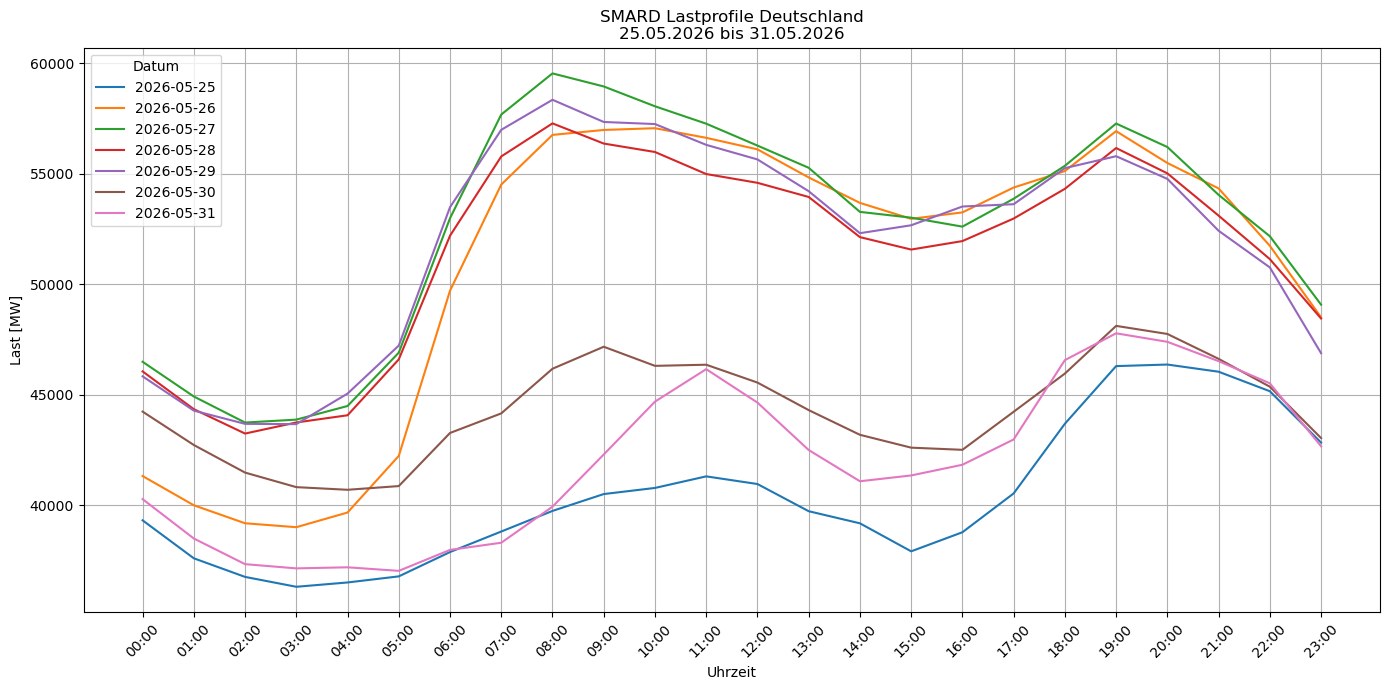

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# SMARD Lastdaten abrufen
# =========================

# Stromverbrauch gesamt Deutschland
FILTER = "410"
REGION = "DE"

# Liste verfügbarer Dateien abrufen
index_url = (
    f"https://www.smard.de/app/chart_data/"
    f"{FILTER}/{REGION}/index_hour.json"
)

response = requests.get(index_url)
response.raise_for_status()

timestamps = response.json()["timestamps"]

# Alle Daten laden
all_data = []

for ts in timestamps:

    data_url = (
        f"https://www.smard.de/app/chart_data/"
        f"{FILTER}/{REGION}/"
        f"{FILTER}_{REGION}_hour_{ts}.json"
    )

    try:
        r = requests.get(data_url)
        r.raise_for_status()

        data = r.json()["series"]

        for row in data:
            if row[1] is not None:
                all_data.append(row)

    except Exception as e:
        print(f"Fehler bei Timestamp {ts}: {e}")

# =========================
# DataFrame erstellen
# =========================

df = pd.DataFrame(all_data, columns=["timestamp", "load"])

# Zeitstempel umwandeln
df["datetime"] = pd.to_datetime(df["timestamp"], unit="ms")

# Deutsche Zeitzone
df["datetime"] = (
    df["datetime"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("Europe/Berlin")
)

# Zeitraum filtern
start_date = pd.Timestamp(
    "2026-05-25",
    tz="Europe/Berlin"
)

end_date = pd.Timestamp(
    "2026-06-01",
    tz="Europe/Berlin"
)

df = df[
    (df["datetime"] >= start_date) &
    (df["datetime"] < end_date)
]

# =========================
# Tagesprofile vorbereiten
# =========================

df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.strftime("%H:%M")

pivot = df.pivot(
    index="time",
    columns="date",
    values="load"
)

# =========================
# Plot
# =========================

plt.figure(figsize=(14, 7))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        label=str(col)
    )

plt.title(
    "SMARD Lastprofile Deutschland\n"
    "25.05.2026 bis 31.05.2026"
)

plt.xlabel("Uhrzeit")
plt.ylabel("Last [MW]")

plt.xticks(rotation=45)

plt.grid(True)
plt.legend(title="Datum")

plt.tight_layout()
plt.show()